In [1]:
import sys, os, time, numpy as np, matplotlib.pyplot as plt
from holograPy_functions import points_vector_builder, coords_shape, GF_propagator_function_builder, target_builder_char
home_path = "C:/Users/roadc/OneDrive - University College London/Activation of Metasurface"

In [2]:
def GFGS(H, incident_surface_pressure, abs_target, iterations=50, verbose=False):

    # initialise - target plane pressure
    tpp = abs_target*np.exp(1j*np.pi*abs_target)

    # algorise - run GS
    for it in range(iterations):

        # backpropagate to find surface plane pressure
        spp = np.dot(np.conj(H), tpp)

        # reset amplitude on the surface
        spp = abs(incident_surface_pressure).reshape(-1, 1)*np.exp(1j*np.angle(spp))

        # propagate back to target plane
        tpp = np.dot(H.T, spp)

        # isolate over the target area
        tpp = abs_target*np.exp(1j*np.angle(tpp)*abs_target)

        if verbose:
            print("Iteration:", str(it), "... done!")

    # finalise
    spp = np.dot(np.conj(H), tpp)
    spp = incident_surface_pressure.reshape(-1, 1)*np.exp(1j*np.angle(spp))
    
    return spp

In [3]:
# ----> AMM plane <----
c0 = 343.  # [m/s]
f = 40000
lam = c0/f
k = 2*np.pi/lam

# eval_centrepoint_list = [(0, 0, 5*ref_lam), (0, 0, 10*ref_lam), (0, 0, 15*ref_lam)]

m_AMM, n_AMM = 32, 32
dx_AMM = lam/2 # cell spacing [m]
AMM_centrepoint = (0, 0, 0)
AMM_sidelengths = [((m_AMM/2)*dx_AMM, (m_AMM/2)*dx_AMM), ((n_AMM/2)*dx_AMM, (n_AMM/2)*dx_AMM), (0, 0)]
AMM_points = points_vector_builder(AMM_centrepoint, AMM_sidelengths, dx_AMM)

# ----> normals & areas <----
AMM_normals = [np.zeros((1, n_AMM*m_AMM)), np.zeros((1, n_AMM*m_AMM)), np.ones((1, n_AMM*m_AMM))]
AMM_areas = (dx_AMM**2)*np.ones((1, n_AMM*m_AMM))

In [4]:
# ----> evaluation plane <----
eval_res = 4
dx_eval = dx_AMM/eval_res
eval_sidelengths = [((m_AMM*dx_AMM)/2, (m_AMM*dx_AMM)/2),
                    ((n_AMM*dx_AMM)/2, (n_AMM*dx_AMM)/2),
                    (0, 0)] # [(-x, +x), (-y, +y), (-z, +z)]

eval_centrepoint = (0, 0, 10*lam)
eval_points = points_vector_builder(eval_centrepoint, eval_sidelengths, dx_eval)

In [5]:
# create a target image
char = "A"
image_size = eval_res*m_AMM
fontsize = int(1.2*image_size)

font_name = "tahoma"
font_file = "C:/Windows/Fonts/"+font_name+".ttf"

abs_target = target_builder_char(char, font_file, fontsize, image_size, image_size).reshape(-1, 1)
H_AMM_eval = GF_propagator_function_builder(AMM_points, eval_points, AMM_normals, AMM_areas, k)

# pressure incident on the AMM (planewave)
P_AMM_in = np.ones((m_AMM, n_AMM))*np.exp(1j*np.zeros((m_AMM, n_AMM)))

surface_pressure = GFGS(H_AMM_eval, P_AMM_in, abs_target) # surface plane pressure
target_pressure = np.dot(H_AMM_eval.T, surface_pressure) # target plane pressure

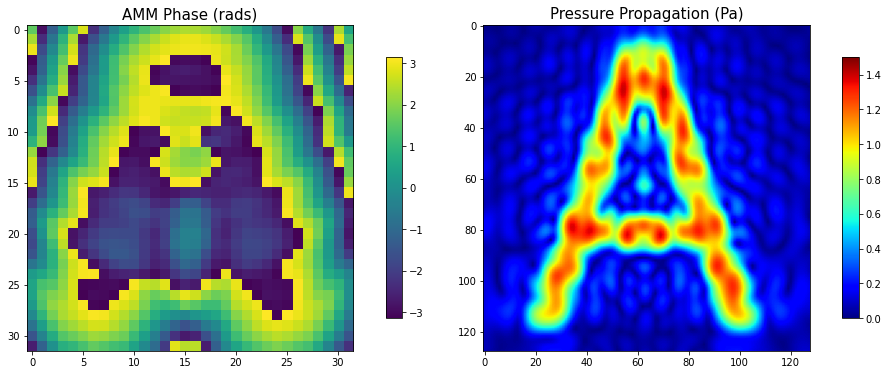

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
im1 = ax1.imshow(np.angle(surface_pressure.reshape(m_AMM, n_AMM)), vmin=-np.pi, vmax=np.pi)
cax = ax1.inset_axes([1.1, 0.1, 0.05, 0.8]) # [x0, y0, width, height]
ax1.set_title("AMM Phase (rads)", fontsize=15)
plt.colorbar(im1, cax=cax)

im2 = ax2.imshow(abs(target_pressure.reshape(m_AMM*eval_res, n_AMM*eval_res)), plt.get_cmap("jet"), vmin=0, vmax=1.5)
cax = ax2.inset_axes([1.1, 0.1, 0.05, 0.8]) # [x0, y0, width, height]
ax2.set_title("Pressure Propagation (Pa)", fontsize=15)
plt.colorbar(im2, cax=cax)
plt.show()